In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"D:\ML\Scikit-Learn-Tutorial-\New ML\train.csv", usecols=['GarageQual','FireplaceQu','SalePrice'])

In [3]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [5]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

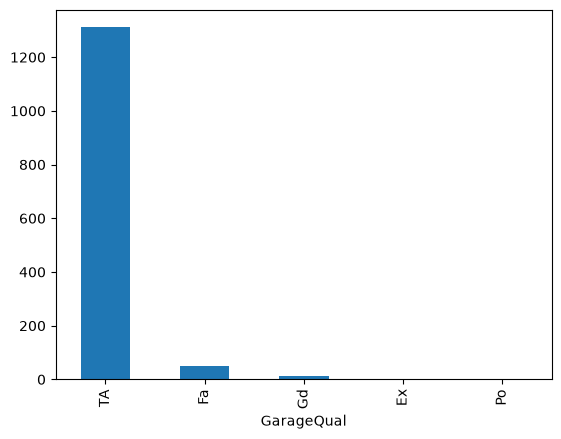

In [6]:
df['GarageQual'].value_counts().plot.bar()

In [7]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

Text(0.5, 1.0, 'GarageQual')

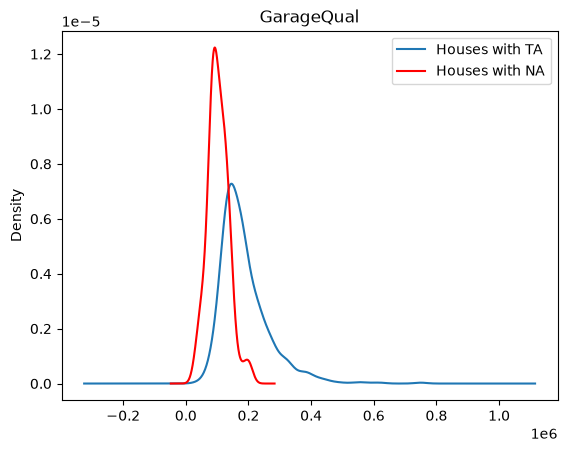

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax = ax, color='red')

lines, label = ax.get_legend_handles_labels()
label=['Houses with TA', 'Houses with NA']
ax.legend(lines,label, loc='best')

plt.title("GarageQual")

In [9]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [11]:
df['GarageQual'] = df['GarageQual'].fillna('TA', inplace=True)


C:\Users\Mohd Shamsher\AppData\Local\Temp\ipykernel_13808\2469024534.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GarageQual'] = df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

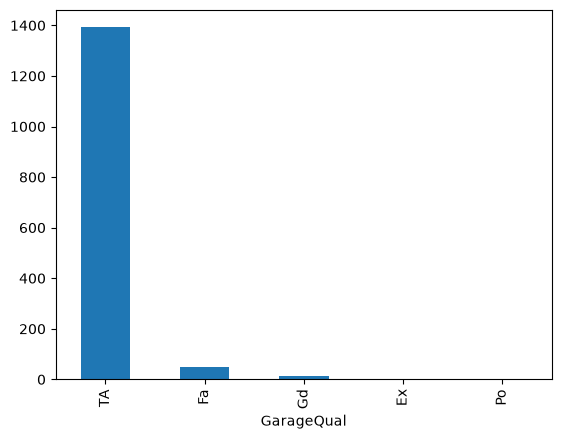

In [14]:
df['GarageQual'].value_counts().plot.bar()

Text(0.5, 1.0, 'GarageQual')

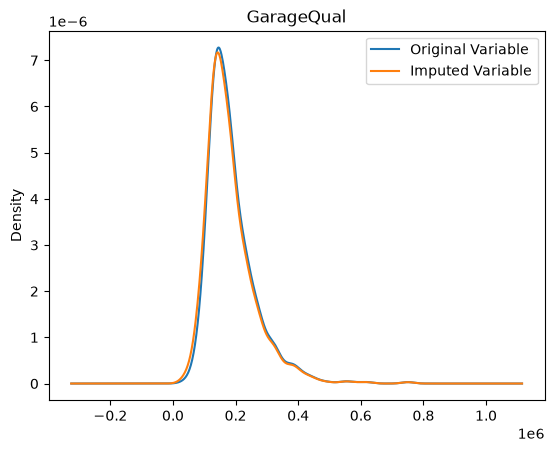

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

lines ,label =ax.get_legend_handles_labels()

label = ['Original Variable', 'Imputed Variable']
ax.legend(lines, label, loc='best')
plt.title('GarageQual')

In [17]:
df.columns

Index(['FireplaceQu', 'GarageQual', 'SalePrice'], dtype='str')

<Axes: xlabel='FireplaceQu'>

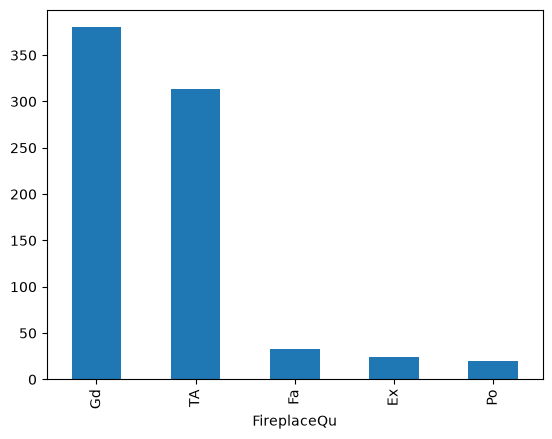

In [18]:
df['FireplaceQu'].value_counts().plot.bar()

In [19]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: str

Text(0.5, 1.0, 'FireplaceQu')

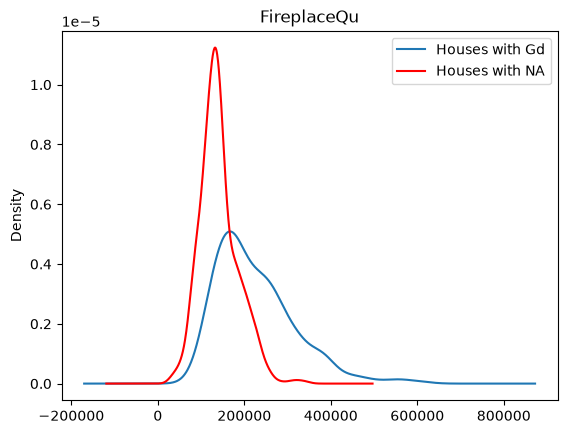

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines , lable = ax.get_legend_handles_labels()

label = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, label , loc='best')
plt.title("FireplaceQu")

In [22]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [23]:
df['FireplaceQu']= df['FireplaceQu'].fillna('Gd')

<Axes: xlabel='FireplaceQu'>

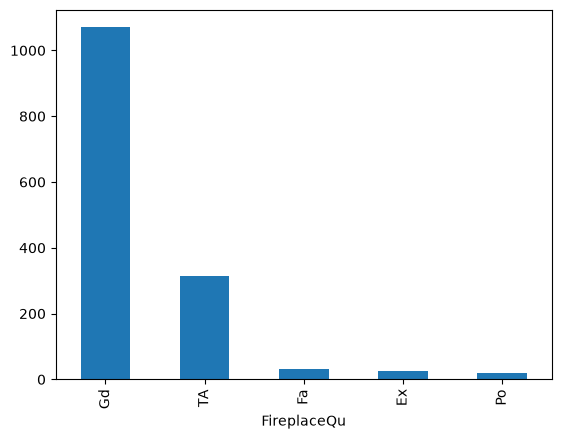

In [24]:
df['FireplaceQu'].value_counts().plot.bar()

Text(0.5, 1.0, 'FireplaceQu')

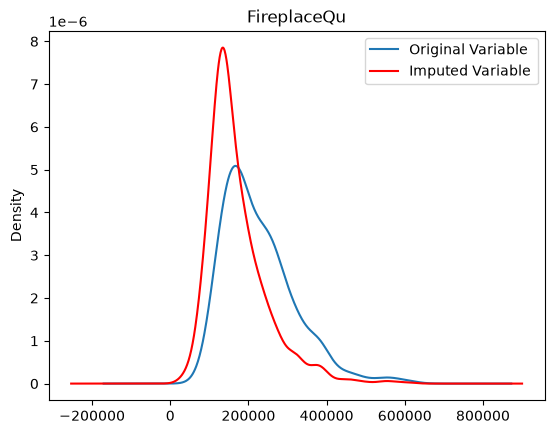

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax , color='red')

lines, label = ax.get_legend_handles_labels()
label =['Original Variable ', 'Imputed Variable']
ax.legend(lines,label,loc='best')

plt.title('FireplaceQu')

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('SalePrice', axis=1),df['SalePrice'],test_size=0.02 ,random_state=42)

In [28]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')

X_train = si.fit_transform(X_train)
X_test = si.transform(X_train)


c:\Users\Mohd Shamsher\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [29]:
si.statistics_

array(['Gd', 'TA'], dtype=object)